In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

##### Carga del dataset

In [2]:
df =  pd.read_csv('../../../data/WineQT.csv')

df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


##### Exploracion inicial y preprocesamiento de datos

In [3]:
# Revision de valores nulos
qsna=df.shape[0]-df.isnull().sum(axis=0)
qna=df.isnull().sum(axis=0)
ppna=round(100*(df.isnull().sum(axis=0)/df.shape[0]),2)
aux= {'datos sin NAs en q': qsna, 'Na en q': qna ,'Na en %': ppna}
na=pd.DataFrame(data=aux)
na.sort_values(by='Na en %',ascending=False).head(20)

,datos sin NAs en q,Na en q,Na en %
fixed acidity,1143,0,0.0
volatile acidity,1143,0,0.0
citric acid,1143,0,0.0
residual sugar,1143,0,0.0
chlorides,1143,0,0.0
free sulfur dioxide,1143,0,0.0
total sulfur dioxide,1143,0,0.0
density,1143,0,0.0
pH,1143,0,0.0
sulphates,1143,0,0.0


In [4]:
# Escalamiento de variables
X = df.drop('quality', axis=1)
y = df['quality']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Aplicacion de PCA

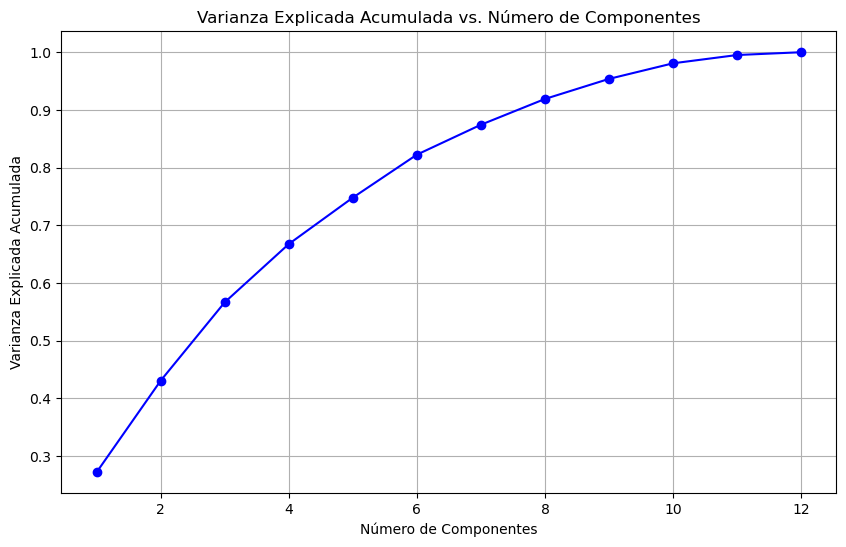

In [5]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calcular varianza explicada acumulada
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)

# Visualización de la varianza explicada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         explained_variance_ratio_cumsum, 'bo-')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada vs. Número de Componentes')
plt.grid(True)
plt.show()

* Se determina que manteniendo 8 componentes, alcanzamos el 90% de la variabilidad, es decir, con 8 nos quedamos 

##### Interpretacion de componentes principales


Coeficientes de los componentes principales:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
PC1        0.476593         -0.204295     0.437978        0.168989   0.219808   
PC2       -0.114893          0.342102    -0.200551        0.217297   0.133251   
PC3       -0.099587         -0.388967     0.249782        0.155761   0.005986   
PC4       -0.237216          0.074252    -0.063247       -0.408790   0.650409   
PC5       -0.067113          0.306379    -0.070518        0.699158   0.331301   
PC6        0.098387          0.108260     0.047173       -0.107865   0.164931   
PC7        0.181878          0.526846     0.066894       -0.098021   0.140352   
PC8        0.314879          0.394574    -0.147274       -0.265587  -0.427604   
PC9        0.207661          0.087619     0.354776       -0.325092   0.312599   
PC10       0.152746         -0.145979    -0.397642        0.040409   0.118121   
PC11      -0.281555          0.341341     0.617207        0.110

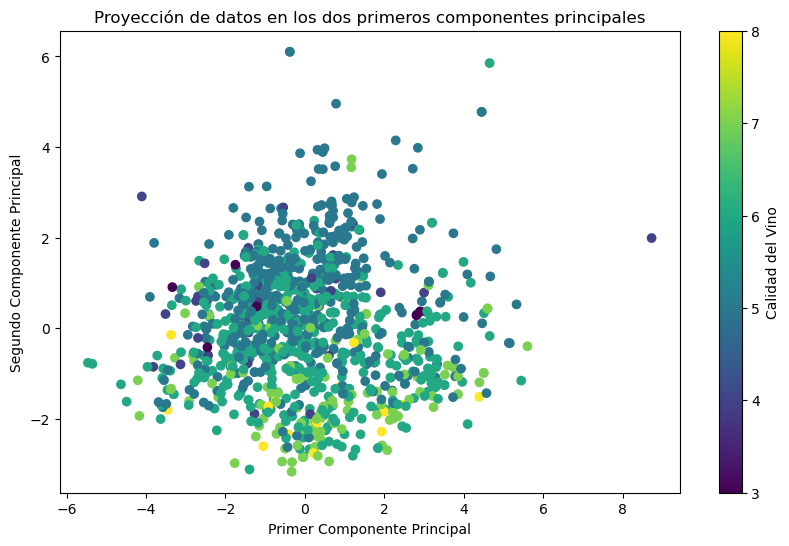

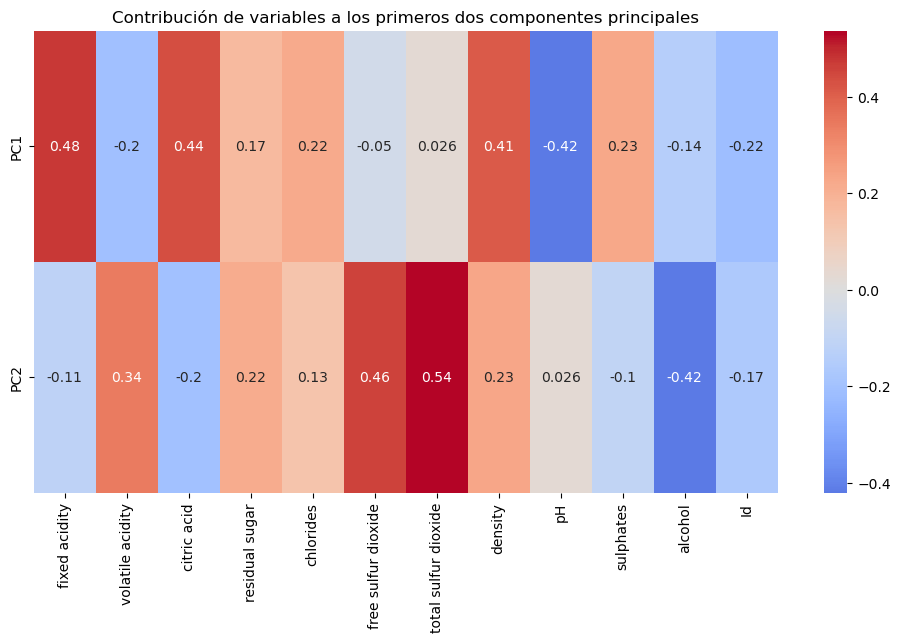

In [6]:
components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

print("\nCoeficientes de los componentes principales:")
print(components_df)

# 5. Visualización en 2D
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.title('Proyección de datos en los dos primeros componentes principales')
plt.colorbar(label='Calidad del Vino')
plt.show()

# Contribución de variables a los primeros dos componentes
plt.figure(figsize=(12, 6))
sns.heatmap(components_df.iloc[:2], annot=True, cmap='coolwarm', center=0)
plt.title('Contribución de variables a los primeros dos componentes principales')
plt.show()

* Se observa que las variables que mas significado aportan a las dos variables principales son el total de sulfuros (46%) y el acido citrico (44%) se denota tambien que aunque en menor medida, las demas variables tambien aportan significado